Sharpness Score: 3402.71
Adaptive Threshold: -58.34
Enhancement not required.


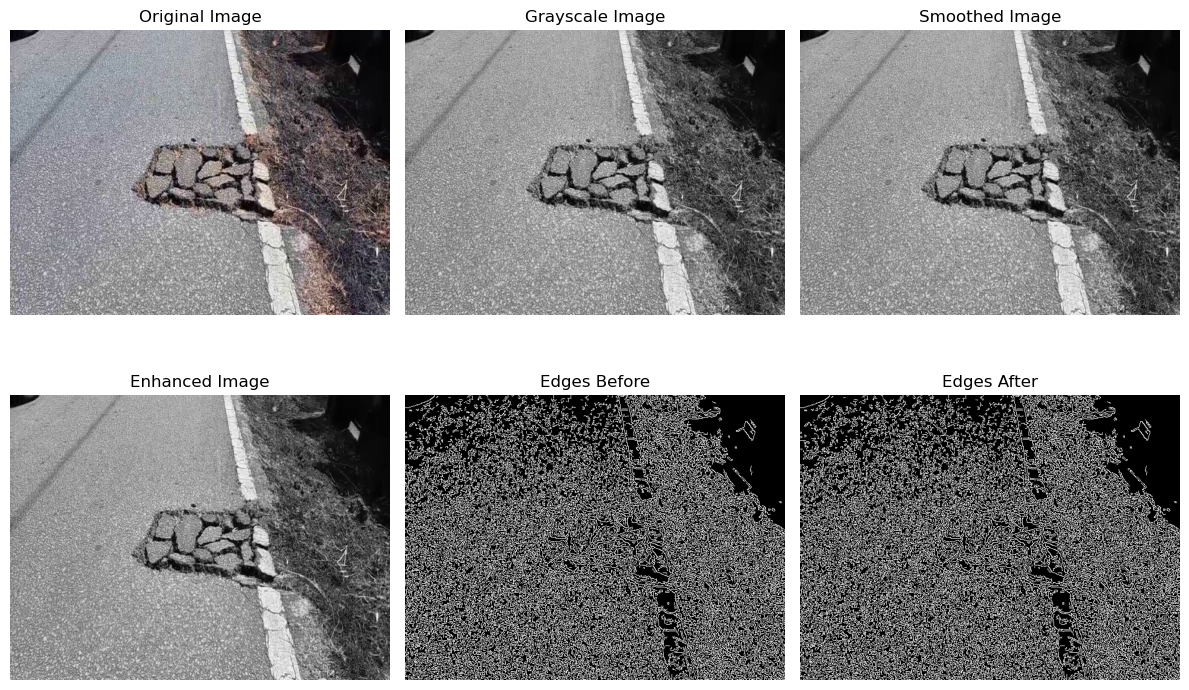

Output image saved to: C:\Users\ASUS\OneDrive\Desktop\image processing project\alligator_enhnaced\adaptive_enhanced_95.jpg


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\image processing project\image processing video\alligator\extracted\95.jpg"

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError("Image not found at the specified path.")

resized = cv2.resize(image, (640, 480))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

def variance_of_laplacian(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return laplacian.var(), laplacian

sharpness_score, laplacian_img = variance_of_laplacian(gray)

print(f"Sharpness Score: {sharpness_score:.2f}")

# Adaptive Threshold
mean_val = np.mean(laplacian_img)
std_val = np.std(laplacian_img)
adaptive_threshold = mean_val - std_val

print(f"Adaptive Threshold: {adaptive_threshold:.2f}")

if sharpness_score < adaptive_threshold:
    print("Enhancing image...")

    smoothed = cv2.GaussianBlur(gray, (5,5), 1.5)
    blur_for_unsharp = cv2.GaussianBlur(smoothed, (9,9), 10)

    enhanced = cv2.addWeighted(
        smoothed, 1.5,
        blur_for_unsharp, -0.5, 0
    )
else:
    print("Enhancement not required.")
    smoothed = gray
    enhanced = gray

edges_before = cv2.Canny(gray, 100, 200)
edges_after = cv2.Canny(enhanced, 100, 200)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Smoothed Image")
plt.imshow(smoothed, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Enhanced Image")
plt.imshow(enhanced, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Edges Before")
plt.imshow(edges_before, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Edges After")
plt.imshow(edges_after, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

output_folder = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\alligator_enhnaced"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "adaptive_enhanced_95.jpg")
cv2.imwrite(output_path, enhanced)

print(f"Output image saved to: {output_path}")